# <font color="#418FDE" size="6.5" uppercase>**Unsupervised Learning and Introductory Generative Models**</font>

>Last update: 20260421.
    
By the end of this Lecture, you will be able to:
- Explain the purpose of unsupervised learning. 
- Describe the basic roles of the generator and discriminator in a generative adversarial network. 
- Explain the basic idea of diffusion-style generative modeling. 


## **1. Unsupervised Representation Learning**

### **1.1. Learning from Unlabeled Data**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_A/image_01_01.jpg?v=1776818748" width="250">



>* Unlabeled images still contain useful patterns.
>* Models learn compact features without costly labels.

>* Representations summarize images using meaningful features.
>* Unlabeled images reveal patterns for discovery.

>* Prepare images, train model, inspect feature patterns.
>* Unlabeled data reveals clusters, anomalies, and structure.



TensorFlow version: 2.21.0
GPU available: False
Training images: 8000
Each image vector: 784
Final training loss: 0.1226
Final validation loss: 0.1252


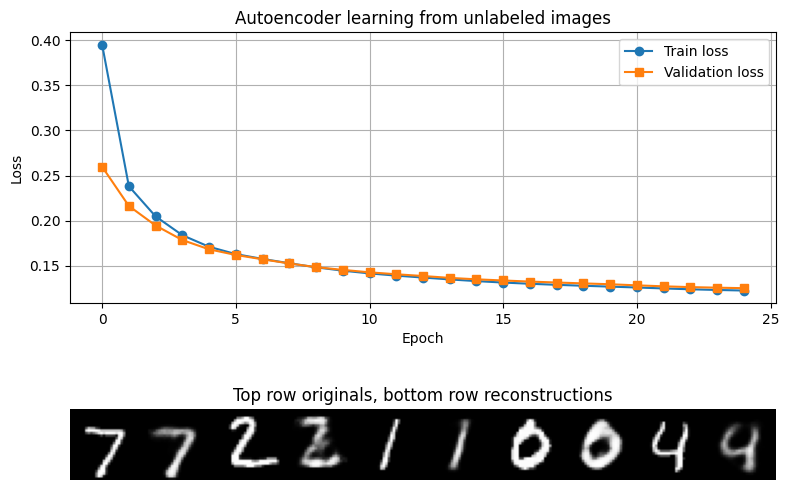

In [19]:
#@title Python Code - Learning from Unlabeled Data

# Unsupervised learning finds patterns without labels.
# Autoencoders compress images into useful features.
# This example uses small MNIST subsets.

# Import quiet libraries for Colab runs.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt

# Import TensorFlow after quiet settings.
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

random.seed(7)
np.random.seed(7)

tf.random.set_seed(7)

# Report TensorFlow version briefly.
print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

# Load unlabeled MNIST image data.
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
train_limit = 8000

test_limit = 1000
x_train = x_train[:train_limit]

x_test = x_test[:test_limit]

# Normalize and flatten image arrays.
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(len(x_train), 784)

x_test = x_test.reshape(len(x_test), 784)

# Check shapes before model training.
assert x_train.shape[1] == 784
assert x_test.shape[1] == 784

print('Training images:', x_train.shape[0])
print('Each image vector:', x_train.shape[1])

# Build a tiny dense autoencoder.
inputs = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(64, activation='relu')(inputs)

bottleneck = tf.keras.layers.Dense(16, activation='relu')(encoded)
decoded = tf.keras.layers.Dense(64, activation='relu')(bottleneck)

auto_outputs = tf.keras.layers.Dense(784, activation='sigmoid')(decoded)
autoencoder = tf.keras.Model(inputs, auto_outputs)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train using images as both targets.
history = autoencoder.fit(
    x_train, x_train,

    epochs=25, batch_size=128,
    validation_data=(x_test, x_test), verbose=0)

# Reconstruct a few test images.
show_count = 5
reconstructions = autoencoder.predict(x_test[:show_count], verbose=0)

print('Final training loss:', round(history.history['loss'][-1], 4))
print('Final validation loss:', round(history.history['val_loss'][-1], 4))

# Create one figure with two panels.
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
axes[0].plot(history.history['loss'], marker='o', label='Train loss')

axes[0].plot(history.history['val_loss'], marker='s', label='Validation loss')
axes[0].set_title('Autoencoder learning from unlabeled images')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[0].grid(True)

# Prepare image strip for comparison.
rows = []
for i in range(show_count):

    rows.append(x_test[i].reshape(28, 28))
    rows.append(reconstructions[i].reshape(28, 28))

# Stack originals and reconstructions vertically.
image_strip = np.concatenate(rows, axis=1)
axes[1].imshow(image_strip, cmap='gray')

axes[1].set_title('Top row originals, bottom row reconstructions')

axes[1].axis('off')
plt.tight_layout()
plt.show()

### **1.2. Autoencoders for Compression**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_A/image_01_02.jpg?v=1776818777" width="250">



>* Autoencoders compress images, then reconstruct them.
>* They learn useful features without labels.

>* Autoencoders learn data-specific image compression.
>* Latent size balance supports useful engineering features.

>* Latent codes support comparison and anomaly detection.
>* Bottlenecks learn useful structure from unlabeled images.



TensorFlow version: 2.21.0
Training device: CPU
Train and test shapes: (12000, 784) (2000, 784)
Latent size: 16 values per image
Compression ratio is about: 49.0 to 1
Encoder maps 784 pixels into 16 numbers
Decoder rebuilds images from that compact code


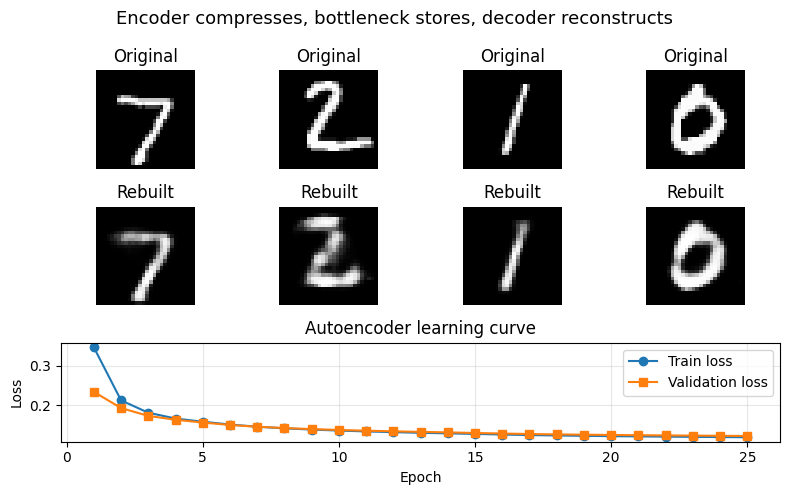

In [20]:
#@title Python Code - Autoencoders for Compression

# Autoencoders learn compact image representations.
# This example uses MNIST digits.
# Small models run quickly in Colab.

# Install packages only if needed.
# !pip install tensorflow matplotlib pandas

import os, warnings, random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")
import tensorflow as tf

tf.get_logger().setLevel("ERROR")

random.seed(7)
np.random.seed(7)
tf.random.set_seed(7)

print("TensorFlow version:", tf.__version__)

# Report available compute device.
gpu_name = tf.config.list_physical_devices("GPU")
device_text = "GPU" if len(gpu_name) > 0 else "CPU"

print("Training device:", device_text)

# Load unlabeled handwritten images.
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Use small subsets for speed.
x_train = x_train[:12000]
x_test = x_test[:2000]

# Scale pixels into zero to one.
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten each image into vectors.
x_train = x_train.reshape(len(x_train), 784)
x_test = x_test.reshape(len(x_test), 784)

# Check shapes before training.
assert x_train.shape[1] == 784
assert x_test.shape[1] == 784

print("Train and test shapes:", x_train.shape, x_test.shape)

# Choose a small bottleneck size.
latent_dim = 16
print("Latent size:", latent_dim, "values per image")

# Build the encoder network.
encoder_input = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(64, activation="relu")(encoder_input)

bottleneck = tf.keras.layers.Dense(latent_dim, activation="relu")(encoded)
encoder = tf.keras.Model(encoder_input, bottleneck)

# Build the decoder network.
decoder_input = tf.keras.Input(shape=(latent_dim,))
decoded = tf.keras.layers.Dense(64, activation="relu")(decoder_input)

decoder_output = tf.keras.layers.Dense(784, activation="sigmoid")(decoded)
decoder = tf.keras.Model(decoder_input, decoder_output)

# Connect encoder and decoder together.
auto_input = tf.keras.Input(shape=(784,))
auto_output = decoder(encoder(auto_input))

autoencoder = tf.keras.Model(auto_input, auto_output)

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy")

# Train quietly on reconstruction task.
history = autoencoder.fit(
    x_train,

    x_train,
    epochs=25,
    batch_size=128,

    validation_data=(x_test, x_test),
    verbose=0)

# Create compressed codes and reconstructions.
latent_codes = encoder.predict(x_test[:8], verbose=0)
reconstructions = autoencoder.predict(x_test[:8], verbose=0)

# Summarize the learned compression idea.
compression_ratio = 784 / latent_dim
print("Compression ratio is about:", round(compression_ratio, 1), "to 1")

print("Encoder maps 784 pixels into", latent_dim, "numbers")
print("Decoder rebuilds images from that compact code")

# Prepare one figure with all results.
fig = plt.figure(figsize=(8, 5))

# Show original images.
for i in range(4):
    ax = plt.subplot(3, 4, i + 1)

    ax.imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax.set_title("Original")
    ax.axis("off")

# Show reconstructed images.
for i in range(4):
    ax = plt.subplot(3, 4, i + 5)

    ax.imshow(reconstructions[i].reshape(28, 28), cmap="gray")
    ax.set_title("Rebuilt")
    ax.axis("off")

# Plot training and validation loss.
ax = plt.subplot(3, 1, 3)
epochs = np.arange(1, len(history.history["loss"]) + 1)

ax.plot(epochs, history.history["loss"], marker="o", label="Train loss")
ax.plot(epochs, history.history["val_loss"], marker="s", label="Validation loss")
ax.set_xlabel("Epoch")

ax.set_ylabel("Loss")
ax.set_title("Autoencoder learning curve")
ax.legend()

ax.grid(True, alpha=0.3)

# Add a simple teaching title.
fig.suptitle(
    "Encoder compresses, bottleneck stores, decoder reconstructs",

    fontsize=13)
plt.tight_layout()
plt.show()

### **1.3. Latent Space Sampling**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_A/image_01_03.jpg?v=1776818807" width="250">



>* Latent space stores compressed shared image features.
>* Sampling reveals learned patterns and output similarity.

>* Latent regions map related visual patterns.
>* Smooth changes reveal useful, structured representations.

>* Compression alone does not ensure useful sampling.
>* Smooth latent spaces reveal meaningful data structure.



TensorFlow version: 2.21.0
Latent shape: (200, 2) | Reconstruction shape: (5, 784)


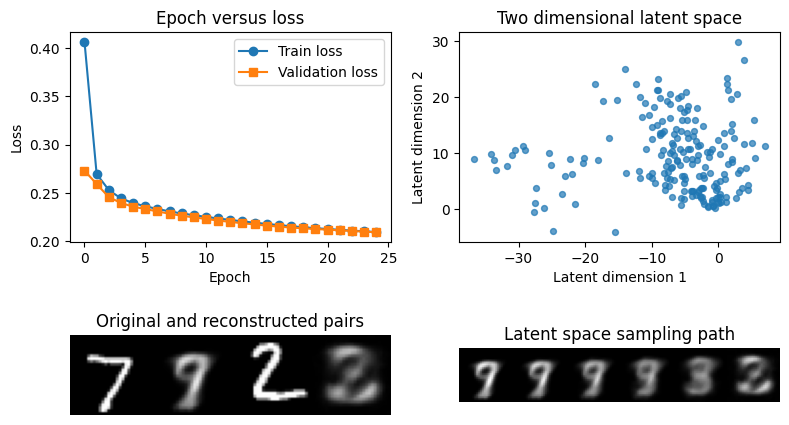

In [21]:
#@title Python Code - Latent Space Sampling

# This script shows simple latent space sampling.
# It uses a tiny MNIST autoencoder example.
# The plots explain unsupervised representation learning.

import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np, matplotlib.pyplot as plt, tensorflow as tf

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
tf.random.set_seed(7)

random.seed(7)

# Report TensorFlow version briefly.
print('TensorFlow version:', tf.__version__)

# Load MNIST image data.
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train[:8000].astype('float32') / 255.0

x_test = x_test[:1000].astype('float32') / 255.0

# Flatten images for dense layers.
if x_train.ndim == 3 and x_test.ndim == 3:
    x_train = x_train.reshape(len(x_train), 784)

    x_test = x_test.reshape(len(x_test), 784)

# Build a tiny two dimensional encoder.
inputs = tf.keras.Input(shape=(784,))
hidden = tf.keras.layers.Dense(64, activation='relu')(inputs)

latent = tf.keras.layers.Dense(2, name='latent_space')(hidden)

# Build a matching decoder network.
decoder_input = tf.keras.Input(shape=(2,))
decoder_hidden = tf.keras.layers.Dense(64, activation='relu')(decoder_input)

decoder_output = tf.keras.layers.Dense(784, activation='sigmoid')(decoder_hidden)

# Connect encoder and decoder models.
encoder = tf.keras.Model(inputs, latent)
decoder = tf.keras.Model(decoder_input, decoder_output)

autoencoder = tf.keras.Model(inputs, decoder(encoder(inputs)))

# Compile the autoencoder model.
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
history = autoencoder.fit(

    x_train, x_train,
    epochs=25,
    batch_size=128,

    validation_data=(x_test, x_test),
    verbose=0)

# Encode and reconstruct a few images.
encoded_test = encoder.predict(x_test[:200], verbose=0)
reconstructed = autoencoder.predict(x_test[:5], verbose=0)

# Create interpolation between two latent points.
start_point = encoded_test[0]
end_point = encoded_test[1]

steps = 6
alpha_values = np.linspace(0.0, 1.0, steps)

# Decode interpolated latent samples.
interpolated_points = []
for alpha in alpha_values:

    point = (1.0 - alpha) * start_point + alpha * end_point
    interpolated_points.append(point)
interpolated_points = np.array(interpolated_points)

interpolated_images = decoder.predict(interpolated_points, verbose=0)

# Build one figure with all results.
fig = plt.figure(figsize=(8, 5))

# Plot training and validation loss.
ax1 = plt.subplot(2, 2, 1)
ax1.plot(history.history['loss'], marker='o', label='Train loss')

ax1.plot(history.history['val_loss'], marker='s', label='Validation loss')
ax1.set_title('Epoch versus loss')
ax1.set_xlabel('Epoch')

ax1.set_ylabel('Loss')
ax1.legend()

# Plot encoded samples in latent space.
ax2 = plt.subplot(2, 2, 2)
ax2.scatter(encoded_test[:, 0], encoded_test[:, 1], s=18, alpha=0.7)

ax2.set_title('Two dimensional latent space')
ax2.set_xlabel('Latent dimension 1')
ax2.set_ylabel('Latent dimension 2')

# Show original and reconstructed images.
ax3 = plt.subplot(2, 2, 3)
comparison = np.hstack([

    x_test[0].reshape(28, 28),
    reconstructed[0].reshape(28, 28),
    x_test[1].reshape(28, 28),

    reconstructed[1].reshape(28, 28)])
ax3.imshow(comparison, cmap='gray')
ax3.set_title('Original and reconstructed pairs')

ax3.axis('off')

# Show decoded interpolation images.
ax4 = plt.subplot(2, 2, 4)
interp_strip = interpolated_images[0].reshape(28, 28)

for i in range(1, steps):
    next_image = interpolated_images[i].reshape(28, 28)
    interp_strip = np.hstack((interp_strip, next_image))

ax4.imshow(interp_strip, cmap='gray')
ax4.set_title('Latent space sampling path')
ax4.axis('off')

# Finish the figure neatly.
plt.tight_layout()
print('Latent shape:', encoded_test.shape, '| Reconstruction shape:', reconstructed.shape)

plt.show()

## **2. Introductory GAN Concepts**

### **2.1. Generator Discriminator Roles**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_A/image_02_01.jpg?v=1776818855" width="250">



>* Generator turns noise into realistic samples.
>* Discriminator judges fakes and guides improvement.

>* Generator learns realistic patterns from data.
>* Discriminator improves by spotting subtle fakes.

>* Balanced training keeps GAN feedback useful.
>* Discriminator critiques; generator learns realistic synthesis.



TensorFlow version: 2.21.0
Using GPU: False
Training images: 2000
Generator turns noise into images.
Discriminator scores real versus fake.
Final generator loss: 0.716
Final discriminator loss: 1.511


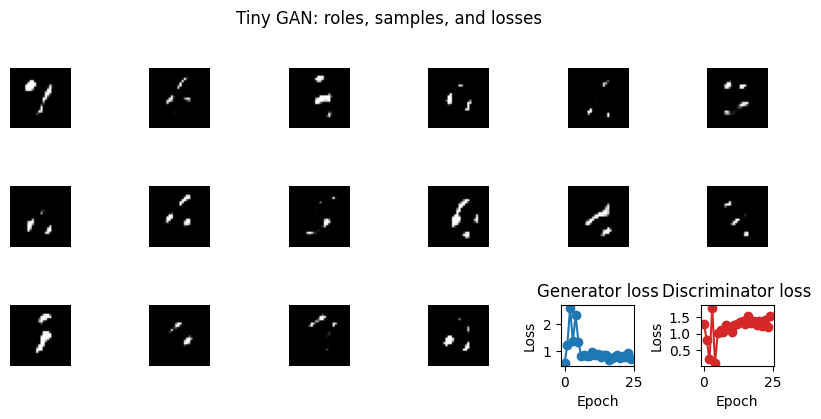

In [22]:
#@title Python Code - Generator Discriminator Roles

# Tiny GAN roles for beginners.
# Generator makes images from noise.
# Discriminator judges real or fake.

# Install TensorFlow only if needed.
# !pip install tensorflow==2.20.0

# Reduce warnings from TensorFlow.
import os, warnings, math
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np

# Import plotting and TensorFlow.
import matplotlib.pyplot as plt
import tensorflow as tf

tf.get_logger().setLevel('ERROR')
SEED = 7

# Set deterministic random seeds.
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)

# Report available compute device.
gpu_name = tf.config.list_physical_devices('GPU')
use_gpu = len(gpu_name) > 0

print('Using GPU:' , use_gpu)

# Load MNIST handwritten digits.
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
small_count = 2000

x_train = x_train[:small_count]

# Scale images to minus one.
x_train = x_train.astype('float32')
x_train = (x_train / 127.5) - 1.0

x_train = np.expand_dims(x_train, axis=-1)

# Check image shape safely.
if x_train.shape[1:] != (28, 28, 1):
    raise ValueError('Unexpected image shape.')

print('Training images:', x_train.shape[0])

# Build a tiny generator.
noise_dim = 64
generator = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(noise_dim,)),
    tf.keras.layers.Dense(7 * 7 * 32),
    tf.keras.layers.LeakyReLU(0.2),

    tf.keras.layers.Reshape((7, 7, 32)),
    tf.keras.layers.UpSampling2D(),
    tf.keras.layers.Conv2D(32, 3, padding='same'),

    tf.keras.layers.LeakyReLU(0.2),

    tf.keras.layers.UpSampling2D(),
    tf.keras.layers.Conv2D(16, 3, padding='same'),
    tf.keras.layers.LeakyReLU(0.2),

    tf.keras.layers.Conv2D(1, 3, padding='same', activation='tanh')])

# Build a tiny discriminator.
discriminator = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(16, 3, strides=2, padding='same'),
    tf.keras.layers.LeakyReLU(0.2),

    tf.keras.layers.Conv2D(32, 3, strides=2, padding='same'),
    tf.keras.layers.LeakyReLU(0.2),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(1)])

# Create loss and optimizers.
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)
g_optimizer = tf.keras.optimizers.Adam(0.0005)

d_optimizer = tf.keras.optimizers.Adam(0.0005)

# Prepare a small dataset.
batch_size = 64
dataset = tf.data.Dataset.from_tensor_slices(x_train)

dataset = dataset.shuffle(512, seed=SEED)
dataset = dataset.batch(batch_size, drop_remainder=True)

# Store losses for plotting.
g_losses = []
d_losses = []

fixed_noise = tf.random.normal([16, noise_dim], seed=SEED)

# Train one batch step.
def train_step(real_images):
    noise = tf.random.normal([batch_size, noise_dim])

    with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
        fake_images = generator(noise, training=True)

        real_logits = discriminator(real_images, training=True)
        fake_logits = discriminator(fake_images, training=True)
        g_loss = loss_fn(tf.ones_like(fake_logits), fake_logits)

        d_real = loss_fn(tf.ones_like(real_logits), real_logits)
        d_fake = loss_fn(tf.zeros_like(fake_logits), fake_logits)
        d_loss = d_real + d_fake

    g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
    d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
    g_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))

    d_optimizer.apply_gradients(zip(d_grads, discriminator.trainable_variables))
    return g_loss, d_loss

# Run a few short epochs.
epochs = 25
for epoch in range(epochs):

    g_epoch = []
    d_epoch = []

    for real_batch in dataset:
        g_loss, d_loss = train_step(real_batch)
        g_epoch.append(float(g_loss.numpy()))

        d_epoch.append(float(d_loss.numpy()))

    g_losses.append(np.mean(g_epoch))
    d_losses.append(np.mean(d_epoch))

# Explain model roles simply.
print('Generator turns noise into images.')
print('Discriminator scores real versus fake.')

print('Final generator loss:', round(g_losses[-1], 3))
print('Final discriminator loss:', round(d_losses[-1], 3))

# Create generated sample images.
generated = generator(fixed_noise, training=False).numpy()
generated = (generated + 1.0) / 2.0

generated = np.clip(generated, 0.0, 1.0)

# Build one figure with subplots.
fig = plt.figure(figsize=(8, 5))
fig.suptitle('Tiny GAN: roles, samples, and losses')

# Show generated image grid.
for i in range(16):
    ax = plt.subplot(4, 6, i + 1)

    ax.imshow(generated[i, :, :, 0], cmap='gray')
    ax.axis('off')

# Plot generator loss separately.
ax1 = plt.subplot(4, 6, 17)
ax1.plot(g_losses, marker='o', color='tab:blue')

ax1.set_title('Generator loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

# Plot discriminator loss separately.
ax2 = plt.subplot(4, 6, 18)
ax2.plot(d_losses, marker='o', color='tab:red')

ax2.set_title('Discriminator loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')

# Tighten layout for display.
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### **2.2. Lightweight GAN Example**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_A/image_02_02.jpg?v=1776818893" width="250">



>* Generator and discriminator learn through competition.
>* Small setups reveal core GAN behavior.

>* Narrow datasets clarify adversarial GAN learning.
>* Outputs evolve, aiding engineering image augmentation.

>* Monitor realism, diversity, and training balance.
>* Use failures to understand GAN behavior.



TensorFlow version: 2.21.0
Device: CPU used
Generator makes images from random noise.
Discriminator judges real versus generated images.
Training alternates both models in competition.
Final generator loss: 0.943
Final discriminator loss: 1.22


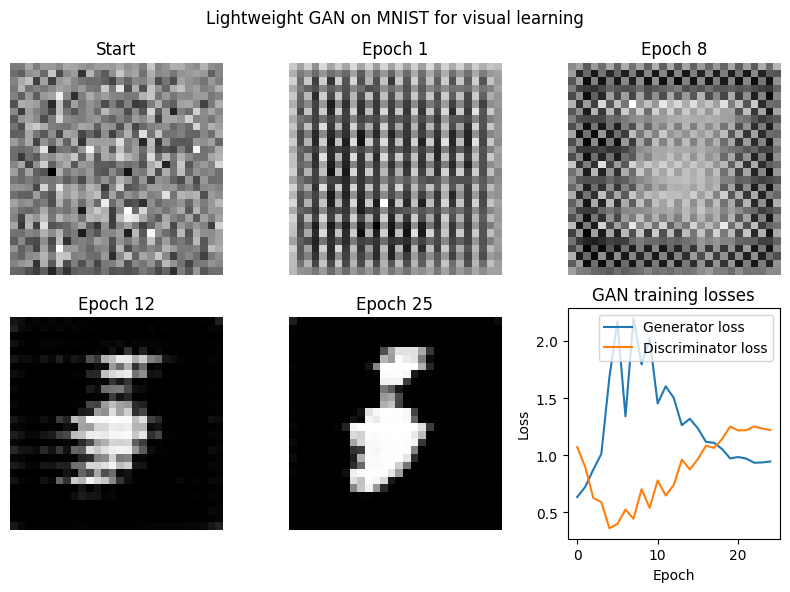

In [23]:
#@title Python Code - Lightweight GAN Example

# This script shows a tiny GAN example.
# It uses MNIST for simple image generation.
# Civil students can watch adversarial learning.

# Install TensorFlow only if needed.
# !pip install tensorflow==2.20.0

# Reduce TensorFlow warning messages.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np, pandas as pd

# Import plotting and TensorFlow tools.
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
tf.random.set_seed(7)

random.seed(7)

# Choose GPU when available.
device_name = tf.config.list_physical_devices('GPU')
use_gpu = len(device_name) > 0

print('TensorFlow version:', tf.__version__)

# Report the selected device.
if use_gpu:
    print('Device: GPU available')

else:
    print('Device: CPU used')

# Load MNIST handwritten digit images.
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
small_count = 2000

x_train = x_train[:small_count]
y_train = y_train[:small_count]

# Check the image array shape.
if len(x_train.shape) != 3:
    raise ValueError('Unexpected MNIST image shape')

if x_train.shape[1] != 28:
    raise ValueError('Expected image height 28')

# Scale pixels to minus one and one.
x_train = x_train.astype('float32')
x_train = (x_train - 127.5) / 127.5

x_train = np.expand_dims(x_train, axis=-1)

# Build a small TensorFlow dataset.
batch_size = 64
latent_dim = 64

epochs = 25
buffer_size = int(x_train.shape[0])

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(buffer_size, seed=7)
dataset = dataset.batch(batch_size, drop_remainder=True)

dataset = dataset.prefetch(tf.data.AUTOTUNE)

# Create the generator network.
generator = tf.keras.Sequential([
    layers.Input(shape=(latent_dim,)),

    layers.Dense(7 * 7 * 64),
    layers.LeakyReLU(0.2),
    layers.Reshape((7, 7, 64)),

    layers.Conv2DTranspose(32, 4, strides=2, padding='same'),
    layers.LeakyReLU(0.2),
    layers.Conv2DTranspose(16, 4, strides=2, padding='same'),

    layers.LeakyReLU(0.2),

    layers.Conv2D(1, 3, padding='same', activation='tanh')])

# Create the discriminator network.
discriminator = tf.keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, 4, strides=2, padding='same'),
    layers.LeakyReLU(0.2),
    layers.Dropout(0.2),

    layers.Conv2D(64, 4, strides=2, padding='same'),
    layers.LeakyReLU(0.2),
    layers.Dropout(0.2),

    layers.Flatten(),

    layers.Dense(1)])

# Define losses and optimizers.
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)
g_optimizer = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)

d_optimizer = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)

# Prepare fixed noise for snapshots.
fixed_noise = tf.random.normal([16, latent_dim], seed=7)
g_loss_history = []

d_loss_history = []
snapshot_images = []

# Train one GAN step manually.
def train_step(real_images):
    noise = tf.random.normal([batch_size, latent_dim])

    with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
        fake_images = generator(noise, training=True)
        real_logits = discriminator(real_images, training=True)

        fake_logits = discriminator(fake_images, training=True)

        d_real_loss = loss_fn(tf.ones_like(real_logits), real_logits)
        d_fake_loss = loss_fn(tf.zeros_like(fake_logits), fake_logits)
        d_loss = d_real_loss + d_fake_loss

        g_loss = loss_fn(tf.ones_like(fake_logits), fake_logits)

    g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
    d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
    g_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))

    d_optimizer.apply_gradients(zip(d_grads, discriminator.trainable_variables))

    return float(g_loss.numpy()), float(d_loss.numpy())

# Save generated images for later display.
def save_snapshot():
    generated = generator(fixed_noise, training=False)

    generated = (generated + 1.0) / 2.0
    generated = tf.clip_by_value(generated, 0.0, 1.0)
    snapshot_images.append(generated.numpy())

# Explain the learning roles briefly.
print('Generator makes images from random noise.')
print('Discriminator judges real versus generated images.')

print('Training alternates both models in competition.')

# Store the starting generator output.
save_snapshot()
for epoch in range(epochs):

    g_epoch = []
    d_epoch = []
    for real_batch in dataset:

        g_value, d_value = train_step(real_batch)
        g_epoch.append(g_value)
        d_epoch.append(d_value)

    g_loss_history.append(float(np.mean(g_epoch)))
    d_loss_history.append(float(np.mean(d_epoch)))
    if epoch in [0, 3, 7, 11]:

        save_snapshot()

# Summarize the final losses.
print('Final generator loss:', round(g_loss_history[-1], 3))
print('Final discriminator loss:', round(d_loss_history[-1], 3))

# Create one figure with snapshots and losses.
fig = plt.figure(figsize=(8, 6))
plot_index = 1

labels = ['Start', 'Epoch 1', 'Epoch 8', 'Epoch 12', 'Epoch 25']

# Show one sample image from each snapshot.
for i in range(len(snapshot_images)):
    ax = plt.subplot(2, 3, plot_index)

    ax.imshow(snapshot_images[i][0, :, :, 0], cmap='gray')
    ax.set_title(labels[i])
    ax.axis('off')

    plot_index = plot_index + 1

# Plot generator and discriminator losses.
ax = plt.subplot(2, 3, 6)
ax.plot(g_loss_history, label='Generator loss')

ax.plot(d_loss_history, label='Discriminator loss')
ax.set_title('GAN training losses')
ax.set_xlabel('Epoch')

ax.set_ylabel('Loss')
ax.legend()

# Add a simple teaching title.
fig.suptitle('Lightweight GAN on MNIST for visual learning')
plt.tight_layout()

plt.show()

### **2.3. GAN Stability Monitoring**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_A/image_02_03.jpg?v=1776818934" width="250">



>* Monitor generator-discriminator balance during training.
>* Check images, diversity, and discriminator behavior.

>* Watch for mode collapse and oscillation.
>* Track samples, confidence, and adjust training.

>* Monitor outputs, curves, and notes each run.
>* Save checkpoints to link changes and instability.



TensorFlow version: 2.21.0
Training device: CPU
Epochs trained: 8
Final generator loss: 0.813
Final discriminator loss: 1.374
Final diversity score: 0.2519
Worse panel repeats one image, like mode collapse.


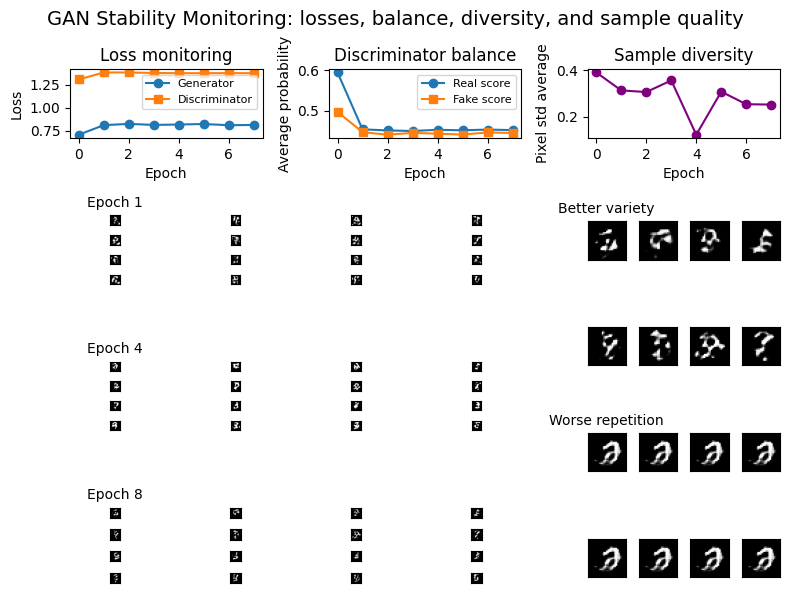

In [24]:
#@title Python Code - GAN Stability Monitoring

# Lightweight GAN monitoring example.
# MNIST images show training stability.
# Civil engineering students inspect diagnostics.

# Import quiet libraries first.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np, pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import layers

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
tf.random.set_seed(7)

random.seed(7)

# Report framework and device.
gpu_name = tf.config.list_physical_devices('GPU')
device_text = 'GPU' if len(gpu_name) > 0 else 'CPU'

print('TensorFlow version:', tf.__version__)
print('Training device:', device_text)

# Load and scale MNIST images.
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32')

x_train = (x_train - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

# Keep a small training subset.
train_count = 4000
x_train = x_train[:train_count]

if x_train.shape[1:] != (28, 28, 1):
    raise ValueError('Unexpected image shape found.')

# Build a tiny generator.
latent_dim = 32

generator = keras.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(7 * 7 * 32),

    layers.LeakyReLU(0.2),
    layers.Reshape((7, 7, 32)),
    layers.UpSampling2D(),

    layers.Conv2D(32, 3, padding='same'),
    layers.LeakyReLU(0.2),
    layers.UpSampling2D(),

    layers.Conv2D(16, 3, padding='same'),
    layers.LeakyReLU(0.2),
    layers.Conv2D(1, 3, padding='same', activation='tanh')])

# Build a tiny discriminator.
discriminator = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(16, 3, strides=2, padding='same'),
    layers.LeakyReLU(0.2),
    layers.Dropout(0.2),

    layers.Conv2D(32, 3, strides=2, padding='same'),
    layers.LeakyReLU(0.2),
    layers.Dropout(0.2),

    layers.Flatten(),
    layers.Dense(1)])

# Create optimizers and loss.
loss_fn = keras.losses.BinaryCrossentropy(from_logits=True)
g_opt = keras.optimizers.Adam(0.0008, beta_1=0.5)

d_opt = keras.optimizers.Adam(0.0008, beta_1=0.5)

# Prepare fixed noise snapshots.
fixed_noise = tf.random.normal((16, latent_dim), seed=11)
snapshot_epochs = [1, 4, 8]

snapshot_images = {}

# Store simple diagnostics.
g_losses = []
d_losses = []

d_real_scores = []
d_fake_scores = []
diversity_scores = []

# Make a small dataset.
batch_size = 64
dataset = tf.data.Dataset.from_tensor_slices(x_train)

dataset = dataset.shuffle(train_count, seed=7)
dataset = dataset.batch(batch_size, drop_remainder=True)

# Train for a few epochs.
epochs = 8
for epoch in range(1, epochs + 1):

    epoch_g = []
    epoch_d = []
    epoch_real = []

    epoch_fake = []

    for real_images in dataset:
        noise = tf.random.normal((batch_size, latent_dim))
        fake_images = generator(noise, training=True)

        with tf.GradientTape() as tape_d:
            real_logits = discriminator(real_images, training=True)
            fake_logits = discriminator(fake_images, training=True)

            real_labels = tf.ones_like(real_logits) * 0.9
            fake_labels = tf.zeros_like(fake_logits)
            d_loss_real = loss_fn(real_labels, real_logits)

            d_loss_fake = loss_fn(fake_labels, fake_logits)
            d_loss = d_loss_real + d_loss_fake

        d_grads = tape_d.gradient(
            d_loss,
            discriminator.trainable_variables)

        d_opt.apply_gradients(
            zip(d_grads, discriminator.trainable_variables))

        noise = tf.random.normal((batch_size, latent_dim))
        with tf.GradientTape() as tape_g:
            generated = generator(noise, training=True)

            fake_logits = discriminator(generated, training=True)
            trick_labels = tf.ones_like(fake_logits)
            g_loss = loss_fn(trick_labels, fake_logits)

        g_grads = tape_g.gradient(
            g_loss,
            generator.trainable_variables)

        g_opt.apply_gradients(
            zip(g_grads, generator.trainable_variables))

        epoch_g.append(float(g_loss.numpy()))
        epoch_d.append(float(d_loss.numpy()))
        epoch_real.append(float(tf.reduce_mean(tf.sigmoid(real_logits)).numpy()))

        epoch_fake.append(float(tf.reduce_mean(tf.sigmoid(fake_logits)).numpy()))

    # Save epoch summaries.
    g_losses.append(np.mean(epoch_g))
    d_losses.append(np.mean(epoch_d))

    d_real_scores.append(np.mean(epoch_real))
    d_fake_scores.append(np.mean(epoch_fake))

    # Measure simple diversity.
    sample_batch = generator(fixed_noise, training=False).numpy()
    diversity_value = np.mean(np.std(sample_batch, axis=0))

    diversity_scores.append(float(diversity_value))

    # Save selected image grids.
    if epoch in snapshot_epochs:
        snapshot_images[epoch] = sample_batch.copy()

# Create a worse comparison set.
mode_noise = tf.random.normal((1, latent_dim), seed=21)
mode_image = generator(mode_noise, training=False).numpy()[0]

worse_images = np.repeat(mode_image[None, ...], 16, axis=0)

# Print short monitoring summary.
print('Epochs trained:', epochs)
print('Final generator loss:', round(g_losses[-1], 3))

print('Final discriminator loss:', round(d_losses[-1], 3))
print('Final diversity score:', round(diversity_scores[-1], 4))
print('Worse panel repeats one image, like mode collapse.')

# Build one figure with all diagnostics.
fig = plt.figure(figsize=(8, 6))
outer = fig.add_gridspec(4, 3, height_ratios=[1.0, 1.0, 1.0, 1.1])

# Plot loss curves.
ax1 = fig.add_subplot(outer[0, 0])
ax1.plot(g_losses, marker='o', label='Generator')

ax1.plot(d_losses, marker='s', label='Discriminator')
ax1.set_title('Loss monitoring')
ax1.set_xlabel('Epoch')

ax1.set_ylabel('Loss')
ax1.legend(fontsize=8)

# Plot discriminator confidence.
ax2 = fig.add_subplot(outer[0, 1])
ax2.plot(d_real_scores, marker='o', label='Real score')

ax2.plot(d_fake_scores, marker='s', label='Fake score')
ax2.set_title('Discriminator balance')
ax2.set_xlabel('Epoch')

ax2.set_ylabel('Average probability')
ax2.legend(fontsize=8)

# Plot diversity trend.
ax3 = fig.add_subplot(outer[0, 2])
ax3.plot(diversity_scores, marker='o', color='purple')

ax3.set_title('Sample diversity')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Pixel std average')

# Add generated image grids.
row_epochs = [1, 4, 8]
for row_index in range(3):

    epoch_value = row_epochs[row_index]
    subgrid = outer[row_index + 1, 0:2].subgridspec(4, 4)
    images = snapshot_images[epoch_value]

    for image_index in range(16):
        ax = fig.add_subplot(subgrid[image_index // 4, image_index % 4])
        ax.imshow(images[image_index, :, :, 0], cmap='gray')

        ax.set_xticks([])
        ax.set_yticks([])
        if image_index == 0:

            ax.set_title('Epoch ' + str(epoch_value), fontsize=10)

# Add better versus worse comparison.
compare_grid = outer[1:4, 2].subgridspec(4, 4)
for image_index in range(8):

    ax = fig.add_subplot(compare_grid[image_index // 4, image_index % 4])
    ax.imshow(snapshot_images[8][image_index, :, :, 0], cmap='gray')
    ax.set_xticks([])

    ax.set_yticks([])
    if image_index == 0:
        ax.set_title('Better variety', fontsize=10)

for image_index in range(8, 16):
    ax = fig.add_subplot(compare_grid[image_index // 4, image_index % 4])
    ax.imshow(worse_images[image_index, :, :, 0], cmap='gray')

    ax.set_xticks([])
    ax.set_yticks([])
    if image_index == 8:

        ax.set_title('Worse repetition', fontsize=10)

# Add a short teaching title.
fig.suptitle(
    'GAN Stability Monitoring: losses, balance, diversity, and sample quality',

    fontsize=14)
plt.tight_layout()
plt.show()

## **3. Introductory Diffusion Models**

### **3.1. Progressive Noise Addition**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_A/image_03_01.jpg?v=1776818980" width="250">



>* Images are gradually corrupted with added noise.
>* Intermediate noisy stages teach damage reversal.

>* Generation becomes gradual denoising, easier to learn.
>* Training learns broad image patterns across corruption.

>* TensorFlow pairs noisy and cleaner images.
>* Noise teaches reversal toward meaningful structure.



TensorFlow version: 2.21.0
Example digit label: 5


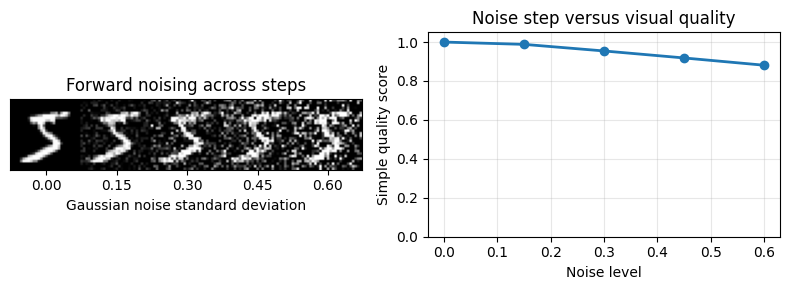

In [25]:
#@title Python Code - Progressive Noise Addition

# This script shows gradual image corruption.
# MNIST digits illustrate diffusion model intuition.
# Civil engineering students can inspect noise.

# Silence TensorFlow and warning messages.
import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np

# Import plotting and TensorFlow tools.
import matplotlib.pyplot as plt
import tensorflow as tf

tf.get_logger().setLevel('ERROR')
np.random.seed(7)

tf.random.set_seed(7)
print('TensorFlow version:', tf.__version__)

# Load MNIST training images safely.
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
if x_train.ndim != 3:

    raise ValueError('Unexpected MNIST image shape.')
image = x_train[0].astype('float32') / 255.0

# Define progressive Gaussian noise levels.
noise_levels = np.array([0.0, 0.15, 0.30, 0.45, 0.60])
if image.shape != (28, 28):

    raise ValueError('Expected one 28 by 28 image.')
noisy_images = []
quality_scores = []

# Create noisy versions step by step.
for level in noise_levels:
    noise = np.random.normal(0.0, level, image.shape)

    noisy = np.clip(image + noise, 0.0, 1.0)
    noisy_images.append(noisy)
    
    # Measure simple visual similarity.
    mse = np.mean((image - noisy) ** 2)
    quality = 1.0 / (1.0 + mse)

    quality_scores.append(quality)

# Convert lists into arrays.
noisy_images = np.array(noisy_images)
quality_scores = np.array(quality_scores)

print('Example digit label:', int(y_train[0]))

# Build one figure with two panels.
fig = plt.figure(figsize=(8, 3))
left = fig.add_subplot(1, 2, 1)

right = fig.add_subplot(1, 2, 2)

# Show image grid on left panel.
grid = np.concatenate(list(noisy_images), axis=1)
left.imshow(grid, cmap='gray', vmin=0.0, vmax=1.0)

left.set_title('Forward noising across steps')
left.set_xticks([14, 42, 70, 98, 126])

# Label each noise step clearly.
left.set_xticklabels(['0.00', '0.15', '0.30', '0.45', '0.60'])
left.set_xlabel('Gaussian noise standard deviation')

left.set_yticks([])

# Plot quality trend on right panel.
right.plot(noise_levels, quality_scores, marker='o', linewidth=2)
right.set_title('Noise step versus visual quality')

right.set_xlabel('Noise level')
right.set_ylabel('Simple quality score')

# Finish layout and display results.
right.set_ylim(0.0, 1.05)
right.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **3.2. Basic Denoising Networks**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_A/image_03_02.jpg?v=1776819009" width="250">



>* Denoising networks learn to remove added noise.
>* Generation emerges through many simple restoration steps.

>* Training uses noisy images with known targets.
>* Convolutions remove noise while preserving details.

>* Repeated denoising turns noise into structure.
>* This process underlies diffusion model learning.



TensorFlow version: 2.21.0
Running on: CPU
This is a tiny denoising autoencoder example.
It is a stepping stone toward diffusion ideas.
Final training loss: 0.0844
Final validation loss: 0.0834


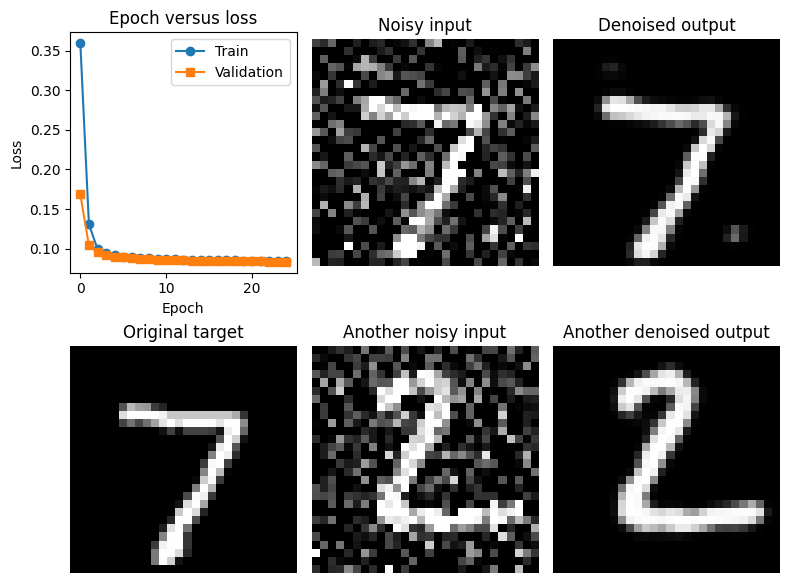

In [26]:
#@title Python Code - Basic Denoising Networks

# Basic denoising networks learn small image repairs.
# This example uses MNIST and TensorFlow.
# It introduces diffusion ideas very simply.

# Import quiet settings and core libraries.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np

# Import plotting and TensorFlow tools.
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
tf.random.set_seed(7)

random.seed(7)

# Report framework and hardware briefly.
gpu_name = 'GPU' if tf.config.list_physical_devices('GPU') else 'CPU'
print('TensorFlow version:', tf.__version__)

print('Running on:', gpu_name)

# Explain the teaching goal briefly.
print('This is a tiny denoising autoencoder example.')
print('It is a stepping stone toward diffusion ideas.')

# Load MNIST grayscale image data.
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
x_train = x_train[:12000]

x_test = x_test[:2000]

# Normalize images and add channels.
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Validate image shapes safely.
if x_train.ndim != 4 or x_test.ndim != 4:
    raise ValueError('Unexpected image tensor shape.')

if x_train.shape[1:] != (28, 28, 1):
    raise ValueError('MNIST images should be 28x28x1.')

# Add small Gaussian noise.
noise_level = 0.35
train_noise = noise_level * np.random.normal(size=x_train.shape)

test_noise = noise_level * np.random.normal(size=x_test.shape)
noisy_train = np.clip(x_train + train_noise, 0.0, 1.0)
noisy_test = np.clip(x_test + test_noise, 0.0, 1.0)

# Build a lightweight denoising autoencoder.
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2, padding='same'),
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),

    keras.layers.UpSampling2D(2),
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(1, 3, activation='sigmoid', padding='same')])

# Compile with a simple reconstruction loss.
model.compile(optimizer='adam', loss='binary_crossentropy')

# Train quietly for a few epochs.
history = model.fit(
    noisy_train,

    x_train,
    epochs=25,
    batch_size=128,

    validation_data=(noisy_test, x_test),
    verbose=0)

# Predict denoised test images.
denoised_test = model.predict(noisy_test[:5], verbose=0)

# Report final losses briefly.
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print('Final training loss:', round(float(train_loss), 4))
print('Final validation loss:', round(float(val_loss), 4))

# Create one figure with all results.
fig = plt.figure(figsize=(8, 6))

# Plot training and validation losses.
ax1 = plt.subplot(2, 3, 1)
ax1.plot(history.history['loss'], marker='o', label='Train')

ax1.plot(history.history['val_loss'], marker='s', label='Validation')
ax1.set_title('Epoch versus loss')
ax1.set_xlabel('Epoch')

ax1.set_ylabel('Loss')
ax1.legend()

# Show noisy examples.
ax2 = plt.subplot(2, 3, 2)
ax2.imshow(noisy_test[0].squeeze(), cmap='gray')

ax2.set_title('Noisy input')
ax2.axis('off')

# Show denoised examples.
ax3 = plt.subplot(2, 3, 3)
ax3.imshow(denoised_test[0].squeeze(), cmap='gray')

ax3.set_title('Denoised output')
ax3.axis('off')

# Show original clean examples.
ax4 = plt.subplot(2, 3, 4)
ax4.imshow(x_test[0].squeeze(), cmap='gray')

ax4.set_title('Original target')
ax4.axis('off')

# Show another noisy example.
ax5 = plt.subplot(2, 3, 5)
ax5.imshow(noisy_test[1].squeeze(), cmap='gray')

ax5.set_title('Another noisy input')
ax5.axis('off')

# Show another denoised example.
ax6 = plt.subplot(2, 3, 6)
ax6.imshow(denoised_test[1].squeeze(), cmap='gray')

ax6.set_title('Another denoised output')
ax6.axis('off')

# Finish and display the figure.
plt.tight_layout()
plt.show()

### **3.3. Toy Sampling Workflow**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_A/image_03_03.jpg?v=1776819040" width="250">



>* Sampling starts from random noise.
>* Repeated denoising gradually forms recognizable images.

>* TensorFlow denoiser cleans noise step by step.
>* Students watch structure emerge in engineering images.

>* Toy diffusion shows iterative error correction.
>* Sample quality depends on noise, steps, model.



TensorFlow version: 2.21.0
GPU available: False
Toy idea: repeated denoising approximates diffusion sampling.
We start from random noise, not a real digit.


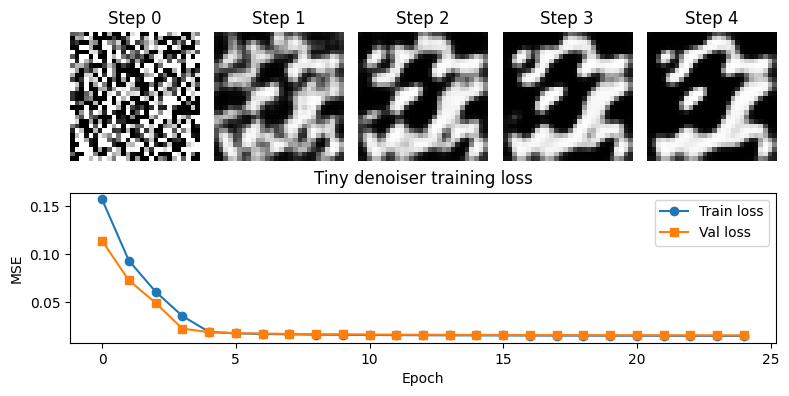

In [27]:
#@title Python Code - Toy Sampling Workflow

# Toy diffusion sampling with MNIST images.
# This script uses a tiny denoiser.
# Results show gradual cleanup steps.

# Import quiet libraries for Colab use.
import os, warnings, numpy as np, matplotlib.pyplot as plt
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import tensorflow as tf

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
tf.random.set_seed(7)

print('TensorFlow version:', tf.__version__)

# Report available compute device simply.
gpu_name = tf.config.list_physical_devices('GPU')
use_gpu = len(gpu_name) > 0

print('GPU available:', use_gpu)

# Load MNIST and scale values.
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0

x_train = np.expand_dims(x_train, axis=-1)

# Keep a small stable subset.
train_count = 4000
if x_train.shape[0] < train_count:

    train_count = x_train.shape[0]

x_clean = x_train[:train_count]
noise = np.random.normal(0.0, 0.5, x_clean.shape)
x_noisy = np.clip(x_clean + noise, 0.0, 1.0)

# Build a tiny denoising network.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(8, 3, padding='same', activation='relu'),
    tf.keras.layers.Conv2D(8, 3, padding='same', activation='relu'),
    tf.keras.layers.Conv2D(1, 3, padding='same', activation='sigmoid')])

# Compile with a simple loss.
model.compile(
    optimizer='adam',

    loss='mse')

# Train quietly for a few epochs.
history = model.fit(
    x_noisy, x_clean,

    epochs=25,
    batch_size=64,
    validation_split=0.1,

    verbose=0)

# Explain this toy workflow briefly.
print('Toy idea: repeated denoising approximates diffusion sampling.')
print('We start from random noise, not a real digit.')

# Create one random starting image.
sample = np.random.normal(0.5, 0.9, (1, 28, 28, 1)).astype('float32')
sample = np.clip(sample, 0.0, 1.0)

steps = [sample[0, :, :, 0].copy()]

# Apply the denoiser several times.
current = sample.copy()
for step_index in range(4):

    current = model.predict(current, verbose=0)
    current = np.clip(current, 0.0, 1.0)
    steps.append(current[0, :, :, 0].copy())

# Prepare one figure with snapshots and loss.
fig = plt.figure(figsize=(8, 4))
for plot_index in range(5):

    ax = plt.subplot(2, 5, plot_index + 1)
    ax.imshow(steps[plot_index], cmap='gray')
    ax.set_title('Step ' + str(plot_index))

    ax.axis('off')

# Plot training and validation loss.
ax = plt.subplot(2, 1, 2)
ax.plot(history.history['loss'], marker='o', label='Train loss')

ax.plot(history.history['val_loss'], marker='s', label='Val loss')
ax.set_title('Tiny denoiser training loss')
ax.set_xlabel('Epoch')

ax.set_ylabel('MSE')
ax.legend()
plt.tight_layout()

plt.show()

# <font color="#418FDE" size="6.5" uppercase>**Unsupervised Learning and Introductory Generative Models**</font>


In this lecture, you learned to:
- Explain the purpose of unsupervised learning. 
- Describe the basic roles of the generator and discriminator in a generative adversarial network. 
- Explain the basic idea of diffusion-style generative modeling. 

In the next Lecture (Lecture B), we will go over 'Introductory NLP, Attention, Transformers, and Multi-Modal Models'